In [1]:
import gzip
import os
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO, Phylo
from dna_features_viewer import GraphicFeature, GraphicRecord

cwd = os.getcwd()
if cwd.endswith('Halocins'):
    os.chdir('../..')
    cwd = os.getcwd()

from src.tree.itol_annotation import (
    itol_labels, 
    itol_color_strip_annotations,
    itol_protein_domain_annotations,
)
from src.tree.tree_util import prune_leaves_with_unknown_id

In [2]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('data/')
assert data_folder.is_dir()

amp_db_folder = data_folder / 'amp_db'
assert amp_db_folder.is_dir()

halocins_folder = amp_db_folder / 'Halocins'
assert halocins_folder.is_dir()

halc8_folder = halocins_folder / 'Halocin_C8'
assert halc8_folder.is_dir()

halc8_out = Path('data/outputs/amp_db/Halocins/Halocin_C8')


In [3]:
gtdb_metadata = pd.read_csv(halc8_out / 'sequences' / 'HalC8_GTDB_r214_metadata.csv', index_col='assembly_accession')

In [4]:
halc8_hits = pd.read_csv(halc8_out / 'sequences' / 'HalC8_GTDB_r214_hits.csv', index_col='id')
halc8_hits.head()

,assembly_accession,protein_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,uniprot_id,length
id,,,,,,,,,,,,
WP_148183473.1@GCF_000008665.1,GCF_000008665.1,WP_148183473.1,Archaea,Halobacteriota,Archaeoglobi,Archaeoglobales,Archaeoglobaceae,Archaeoglobus,Archaeoglobus fulgidus,Archaeoglobus fulgidus DSM 4304,NaN,195
MCS7130230.1@GCA_025058955.1,GCA_025058955.1,MCS7130230.1,Archaea,Halobacteriota,Archaeoglobi,Archaeoglobales,Archaeoglobaceae,WYZ-LMO2,WYZ-LMO2 sp025058955,Archaeoglobaceae archaeon,NaN,263
MCS7131040.1@GCA_025058955.1,GCA_025058955.1,MCS7131040.1,Archaea,Halobacteriota,Archaeoglobi,Archaeoglobales,Archaeoglobaceae,WYZ-LMO2,WYZ-LMO2 sp025058955,Archaeoglobaceae archaeon,NaN,89
WP_139025500.1@GCF_000376445.1,GCF_000376445.1,WP_139025500.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus paucihalophilus,Haladaptatus paucihalophilus DX253,A0A1M7C1A1,287
WP_082837828.1@GCF_001625445.1,GCF_001625445.1,WP_082837828.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus sp001625445,Haladaptatus sp. R4,NaN,266


In [5]:
archaeal_hits = halc8_hits[halc8_hits['domain'] == 'Archaea'].copy()
bacterial_hits = halc8_hits[halc8_hits['domain'] == 'Bacteria'].copy()

In [6]:
def parse_tblout(path):
    return pd.read_csv(
        path, 
        sep='\s+', 
        comment='#', 
        header=None,
        usecols=[0, 3, 13, 17, 18],
        names=[
            'target', 'query', 'score', 'from', 'to'
        ],
    )


pfam_domains = parse_tblout(halc8_folder / 'sequences' / 'pfam_38.domtblout.txt')
tigr_domains = parse_tblout(halc8_folder / 'sequences' / 'tigr.domtblout.txt')
domains = pd.concat([pfam_domains, tigr_domains], ignore_index=True)

domains['target_accession'] = domains['target'].apply(lambda v: v.split('@')[1])
domains['target_protein_id'] = domains['target'].apply(lambda v: v.split('@')[0])

domains = domains.sort_values(['target', 'from', 'to', 'query']).drop_duplicates().reset_index(drop=True)

domains.head()

,target,query,score,from,to,target_accession,target_protein_id
0,AEN07551.1@GCA_000224475.1,TIGR04449,48.3,225,295,GCA_000224475.1,AEN07551.1
1,AOIR01000038.1_26@GCA_000337115.1,TIGR04449,47.3,224,294,GCA_000337115.1,AOIR01000038.1_26
2,ATMD01000005.1_21@GCA_001856825.1,TIGR04449,53.0,123,206,GCA_001856825.1,ATMD01000005.1_21
3,CALUAK010000087.1_2@GCA_943914015.1,TIGR04449,30.0,63,120,GCA_943914015.1,CALUAK010000087.1_2
4,CP002989.1_262@GCA_000224475.1,TIGR04449,48.3,225,295,GCA_000224475.1,CP002989.1_262


In [7]:
domains['query'].value_counts()

TIGR04449       108
Hac8_like_N      21
RHS_repeat        8
TIGR01643         7
TEN_YD-shell      5
TIGR03696         3
DUF6531           1
Name: query, dtype: int64

All proteins contain the Halocin C8 C-ter domain `TIGR04449`:

In [8]:
all_ids = set(halc8_hits.index)
hal_c8_ids = {v.split('$')[0] for v in domains[domains['query'] == 'TIGR04449']['target'].unique()}
assert len(all_ids - hal_c8_ids) == 0

Export Halocin C8 terminal domain into fasta

In [134]:
halc8_trimmed_records = []
for record in SeqIO.parse(halc8_out / 'sequences' / 'HalC8_GTDB_r214_hits.fasta', 'fasta'):
    record.name = ''
    record.description = ''

    row = domains[
        (domains['query'] == 'TIGR04449') &
        (domains['target'] == record.id)
    ].iloc[0]

    start = int(row['from']) - 1
    end = int(row['to']) - 1

    record.seq = record.seq[start:end]

    halc8_trimmed_records.append(record)

with (halc8_out / 'sequences' / 'HalC8_GTDB_r214_hits_TIGR04449.fasta').open('w') as f_out:
    SeqIO.write(halc8_trimmed_records, f_out, 'fasta')

### Tree annotations

In [135]:
labels = []
for raw_id, row in halc8_hits.iterrows():
    tree_id = raw_id.replace('@', '_')
    gtdb_species = row['gtdb_species']
    
    if not pd.isnull(row['uniprot_id']):
        protein_id = row['uniprot_id']
    else:
        protein_id = row['protein_id']
    
    label = f'{gtdb_species} ({protein_id})'
    labels.append([tree_id, label])

itol_labels(
    labels,
    halc8_out / 'tree_full_protein' / 'labels.txt'
)

In [136]:
domain_colors = {
    'Archaea': '#EF7E25',
    'Bacteria': '#036FB1',
}
domain_data = []
for raw_id, row in halc8_hits.iterrows():
    tree_id = raw_id.replace('@', '_')

    domain = row['domain']
    color = domain_colors[domain]

    domain_data.append([tree_id, color, domain])

itol_color_strip_annotations(
    domain_data,
    halc8_out / 'tree_full_protein' / 'domains_color_strip.txt',
    dataset_label='Domain',
    legend_title='Domain',
    color_branches=True,
)

In [137]:
archaeal_class_colors = {
    'Archaeoglobi': '#FF775C',
    'Halobacteria': '#FF5533',
    'Methanomicrobia': '#FF2A00',
    'Methanosarcinia': '#D12300',
    'Thermococci': '#A31B00',
    'Thermoplasmata': '#751400',
    'Thermoprotei A': '#470C00',
}
bacterial_class_colors = {
    'Actinomycetia': '#000075', 
    'Bacilli': '#2E2EFF', 
    'Chloroflexia': '#5C5CFF', 
    'Clostridia': '#8A8AFF',
    'UBA3072': '#B8B8FF',
}
class_colors = archaeal_class_colors
class_colors.update(bacterial_class_colors)

class_data = []
for raw_id, row in halc8_hits.iterrows():
    tree_id = raw_id.replace('@', '_')

    gtdb_class = row['gtdb_class']
    color = class_colors[gtdb_class]

    class_data.append([tree_id, color, gtdb_class])

itol_color_strip_annotations(
    class_data,
    halc8_out / 'tree_full_protein' / 'classes_color_strip.txt',
    dataset_label='Class',
    legend_title='Class',
    color_branches=True,
)

## Protein domains analysis

In [138]:
def find_overlapping_domains(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies overlapping protein domains within a DataFrame.

    This function takes a DataFrame with protein domain annotations and returns a
    new DataFrame containing only the rows where domains on the same target
    protein overlap with at least one other domain.

    Args:
        df: A pandas DataFrame with the following columns:
            - 'query' (str): The name or ID of the domain.
            - 'target' (str): The name or ID of the protein.
            - 'from' (int): The 1-indexed start position of the domain.
            - 'to' (int): The 1-indexed end position of the domain.

    Returns:
        A new pandas DataFrame containing only the rows from the input that
        participate in an overlap. The DataFrame is sorted by the original index.
    """
    df_copy = df.copy()
    df_indexed = df_copy.reset_index()
    merged_df = pd.merge(df_indexed, df_indexed, on='target', suffixes=('_x', '_y'))

    # --- Filter the merged DataFrame to find overlaps ---

    # 1. Remove rows where a domain is compared with itself.
    #    We use the unique 'index' column for this comparison.
    #    Using '<' instead of '!=' is a small optimization to avoid duplicate pairs
    #    (e.g., it keeps (A, B) but discards (B, A)).
    self_comparison_filter = merged_df['index_x'] < merged_df['index_y']
    potential_overlaps = merged_df[self_comparison_filter]

    # 2. Identify the actual overlaps.
    #    An overlap between two intervals [start1, end1] and [start2, end2]
    #    exists if (start1 <= end2) and (start2 <= end1).
    overlap_condition = (potential_overlaps['from_x'] <= potential_overlaps['to_y']) & \
                        (potential_overlaps['from_y'] <= potential_overlaps['to_x'])

    overlapping_pairs = potential_overlaps[overlap_condition]

    # --- Extract and return the original rows ---

    # Get the unique original indices from both sides of the overlapping pairs.
    # .values.ravel('K') flattens the DataFrame columns into a single NumPy array efficiently.
    overlapping_indices = pd.unique(overlapping_pairs[['index_x', 'index_y']].values.ravel('K'))

    # Use the collected indices to select the corresponding rows from the original DataFrame.
    result_df = df.iloc[overlapping_indices].sort_index()

    return result_df.sort_values(['target', 'score'], ascending=False)

In [139]:
overlapping_domains = find_overlapping_domains(domains)
rows_to_keep = set(domains.index) - set(overlapping_domains[overlapping_domains.duplicated(['target'])].index)
domains_dedup = domains.loc[rows_to_keep].reset_index(drop=True)
assert len(find_overlapping_domains(domains_dedup)) == 0
domains_dedup.head()

,target,query,score,from,to,target_accession,target_protein_id
0,AEN07551.1@GCA_000224475.1,TIGR04449,48.3,225,295,GCA_000224475.1,AEN07551.1
1,AOIR01000038.1_26@GCA_000337115.1,TIGR04449,47.3,224,294,GCA_000337115.1,AOIR01000038.1_26
2,ATMD01000005.1_21@GCA_001856825.1,TIGR04449,53.0,123,206,GCA_001856825.1,ATMD01000005.1_21
3,CALUAK010000087.1_2@GCA_943914015.1,TIGR04449,30.0,63,120,GCA_943914015.1,CALUAK010000087.1_2
4,CP002989.1_262@GCA_000224475.1,TIGR04449,48.3,225,295,GCA_000224475.1,CP002989.1_262


In [140]:
domains_dedup['query'].value_counts()

TIGR04449       108
Hac8_like_N      21
TIGR03696         2
RHS_repeat        2
DUF6531           1
TIGR01643         1
TEN_YD-shell      1
Name: query, dtype: int64

In [141]:
domains_dedup_indexed = domains_dedup.sort_values(['target', 'from']).set_index('target')

colorblind_palette = sns.color_palette('colorblind', n_colors=len(domains_dedup['query'].unique())).as_hex()
protein_domain_colors = {}
for i, protein_domain in enumerate(domains_dedup['query'].unique()):
    protein_domain_colors[protein_domain] = colorblind_palette[i]

protein_domain_data = []
for raw_id in domains_dedup_indexed.index:
    rows = domains_dedup_indexed.loc[[raw_id]]
    tree_id = raw_id.replace('@', '_')

    protein_length = int(halc8_hits.loc[raw_id, 'length'])

    data = [tree_id, protein_length]

    for _, row in rows.iterrows():
        protein_domain = row['query']
        from_ = row['from']
        to_ = row['to']
        color = protein_domain_colors[protein_domain]

        row_data = ['RE', str(from_), str(to_), color, protein_domain]

        data.append('|'.join(row_data))

    protein_domain_data.append(data)


itol_protein_domain_annotations(
    protein_domain_data,
    halc8_out / 'tree_full_protein' / 'protein_domain_data.txt',
    dataset_label='Potein domains',
)

## SignalP predictions

In [142]:
signalp = pd.read_csv(halc8_folder / 'sequences' / 'HalC8_GTDB_r214_hits_signalp5.tsv', sep='\t').rename(columns={'ID': 'id'}).set_index('id')
signalp = pd.merge(
    signalp,
    halc8_hits[['domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_genus', 'gtdb_species']],
    how='left',
    on='id',
)
signalp.head()

,Prediction,SP(Sec/SPI),TAT(Tat/SPI),LIPO(Sec/SPII),OTHER,CS Position,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species
id,,,,,,,,,,,,,
AEN07551.1@GCA_000224475.1,OTHER,0.002114,0.001252,0.000272,0.996362,NaN,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halolamina,Halolamina sp000224475
EQB64365.1@GCA_001856825.1,OTHER,0.000782,0.000168,0.000062,0.998988,NaN,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825
DAJC01000023.1_20@GCA_002498845.1,OTHER,0.000766,0.000161,0.000077,0.998996,NaN,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,Thermoplasmataceae,UBA509,UBA509 sp002498845
DARA01000066.1_3@GCA_002503135.1,OTHER,0.001645,0.002752,0.000082,0.995521,NaN,Archaea,Halobacteriota,Methanomicrobia,Methanomicrobiales,Methanoculleaceae,UBA207,UBA207 sp002503135
PWKY01000076.1_62@GCA_003560595.1,OTHER,0.200306,0.102520,0.001289,0.695886,NaN,Archaea,Thermoplasmatota,Thermoplasmata,PWKY01,PWKY01,PWKY01,PWKY01 sp003560595


## Gene neighbourhood

In [143]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(row : pd.Series):
        metadata = row['metadata']
        contig_id = row['contig_id']

        m1 = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        m2 = re.match(r'^ID=([^;]+).*$', metadata)

        if m1 is not None:
            return m1[1]
        elif m2 is not None:
            return contig_id + f"_{m2[1].split('_')[1]}"
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv.apply(parse_protein_id, axis=1)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True).set_index('protein_id')

In [144]:
def get_context(gff_df, core_protein_id, n_upstream=10_000, n_downstream=10_000):
    gff_row = gff_df.loc[core_protein_id]

    contig_id = gff_row['contig_id']
    start = max(gff_row['start'] - n_upstream, 1)
    end = gff_row['end'] + n_downstream

    return gff_df[
        (gff_df['contig_id'] == contig_id) &
        (gff_df['start'] >= start) &
        (gff_df['start'] < end) &
        (gff_df['end'] > start) &
        (gff_df['end'] <= end)
    ].copy()

In [154]:
def plot_genes(aoi_df, color_map=None, label_map=None, ax=None, figure_width=20, no_labels=False, default_color='#cccccc'):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        if no_labels:
            label = None
        elif label_map is not None:
            label = label_map[row.name]
        else:
            label = row['description']
    
        if color_map is not None and row.name in color_map:
            color = color_map[row.name]
        else:
            color = default_color

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

In [146]:
halc8_hits[halc8_hits['gtdb_genus'] == 'Planococcus']

,assembly_accession,protein_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,uniprot_id,length
id,,,,,,,,,,,,
WP_058381518.1@GCF_001465795.2,GCF_001465795.2,WP_058381518.1,Bacteria,Bacillota,Bacilli,Bacillales,Planococcaceae,Planococcus,Planococcus rifietoensis,Planococcus rifietoensis,A0A0U2Z4M8,261
WP_211655516.1@GCF_018283455.1,GCF_018283455.1,WP_211655516.1,Bacteria,Bacillota,Bacilli,Bacillales,Planococcaceae,Planococcus,Planococcus sp018283455,Planococcus sp. MSAK28401,NaN,257
WP_211653467.1@GCF_018283455.1,GCF_018283455.1,WP_211653467.1,Bacteria,Bacillota,Bacilli,Bacillales,Planococcaceae,Planococcus,Planococcus sp018283455,Planococcus sp. MSAK28401,NaN,261


In [ ]:
domains[
    domains['target_accession'] == 'GCF_000230735.2'
]

,target,query,score,from,to,target_accession,target_protein_id
84,WP_015298689.1@GCF_000230735.2,TIGR04449,25.0,204,270,GCF_000230735.2,WP_015298689.1
85,WP_015299009.1@GCF_000230735.2,TIGR04449,47.3,191,264,GCF_000230735.2,WP_015299009.1
86,WP_015299281.1@GCF_000230735.2,Hac8_like_N,125.2,58,162,GCF_000230735.2,WP_015299281.1
87,WP_015299281.1@GCF_000230735.2,TIGR04449,48.6,225,294,GCF_000230735.2,WP_015299281.1
94,WP_081597641.1@GCF_000230735.2,TIGR04449,47.5,196,266,GCF_000230735.2,WP_081597641.1


In [208]:
halc8_data_to_plot = [
    ('GCF_000731985.1', 'WP_007110057.1'),         # Natrinema altunense
    #('GCF_000337175.1', 'WP_241432498.1'),         # Natrinema gari
    ('GCF_000230735.2', 'WP_015299281.1'),         # Natrinema pellirubrum
    ('GCF_000025685.1', 'WP_004043226.1'),         # Haloferax volcanii
    ('GCF_002902305.1', 'WP_103370993.1'),         # Staphylococcus argensis
    #('GCF_002901945.1', 'WP_103159623.1'),         # Staphylococcus chromogenes
    ('GCF_900636325.1', 'NZ_LR134263.1_321'),      # Staphylococcus delphini
    ('GCF_006742205.1', 'WP_002456424.1'),         # Staphylococcus epidermidis
    ('GCF_002902385.1', 'NZ_PPQH01000083.1_2'),    # Staphylococcus intermedius
    ('GCF_900166625.1', 'WP_082233103.1'),         # Halobacillus A massiliensis
    ('GCF_003226345.1', 'WP_110516892.1'),         # Alteribacter lacisalsi
    ('GCF_001465795.2', 'WP_058381518.1'),         # Planococcus rifietoensis
]

context_data = []
upstream = downstream = 10_000
for accession, core_protein_id in halc8_data_to_plot:
    folder = halc8_folder / 'sequences' / 'genomes'
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    gff_file = folder / asm_name / f'{asm_name}_genomic.gff.gz'
    assert gff_file.is_file()

    gff = parse_gff(gff_file)

    strand = gff.loc[core_protein_id, 'strand']

    # Special case for halC8 in Natrinema altunense
    # The RefSeq sequence is missing 105 bp upstream (35 amino acids)
    # (most likely becuse of an inner ATG) 
    if (accession, core_protein_id) == ('GCF_000731985.1', 'WP_007110057.1'):
        assert strand == '-'
        gff.loc[core_protein_id, 'end'] += 105

    gene_context = get_context(
        gff, 
        core_protein_id, 
        n_upstream=upstream if strand == '+' else downstream,
        n_downstream=downstream if strand == '+' else upstream,
    ).reset_index(drop=False)

    gene_context['assembly_accession'] = accession
    gene_context['core_protein_id'] = f'{core_protein_id}@{accession}'

    context_data.append(
        gene_context[[
            'core_protein_id', 'assembly_accession', 'protein_id', 'contig_id', 'source', 'type', 
            'start', 'end', 'na1', 'strand', 'na2', 'metadata', 'description',
        ]]
    )

context_df = pd.concat(context_data, ignore_index=True).set_index('core_protein_id')
context_df.to_csv(halc8_out / 'sequences' / 'gene_context' / 'gene_context.csv')

context_df.head()

,assembly_accession,protein_id,contig_id,source,type,start,end,na1,strand,na2,metadata,description
core_protein_id,,,,,,,,,,,,
WP_007110057.1@GCF_000731985.1,GCF_000731985.1,WP_007110048.1,NZ_JNCS01000004.1,Protein Homology,CDS,306025,306522,.,-,0,ID=cds-WP_007110048.1;Parent=gene-ALTAJ2_RS104...,adenylyltransferase/cytidyltransferase family ...
WP_007110057.1@GCF_000731985.1,GCF_000731985.1,WP_007110049.1,NZ_JNCS01000004.1,Protein Homology,CDS,306519,306959,.,-,0,ID=cds-WP_007110049.1;Parent=gene-ALTAJ2_RS104...,hypothetical protein
WP_007110057.1@GCF_000731985.1,GCF_000731985.1,WP_007110050.1,NZ_JNCS01000004.1,Protein Homology,CDS,307157,309040,.,+,0,ID=cds-WP_007110050.1;Parent=gene-ALTAJ2_RS104...,SLC13 family permease
WP_007110057.1@GCF_000731985.1,GCF_000731985.1,WP_007110051.1,NZ_JNCS01000004.1,Protein Homology,CDS,309046,309225,.,-,0,ID=cds-WP_007110051.1;Parent=gene-ALTAJ2_RS104...,hypothetical protein
WP_007110057.1@GCF_000731985.1,GCF_000731985.1,WP_007110052.1,NZ_JNCS01000004.1,Protein Homology,CDS,309280,309591,.,-,0,ID=cds-WP_007110052.1;Parent=gene-ALTAJ2_RS104...,hypothetical protein


### Export all proteins in neighbourhood

In [209]:
gene_context_records = []
for accession, core_protein_id in halc8_data_to_plot:
    folder = halc8_folder / 'sequences' / 'genomes'
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    protein_fasta_file = folder / asm_name / f'{asm_name}_protein.faa.gz'
    assert protein_fasta_file.is_file()

    with gzip.open(protein_fasta_file, 'rt') as f_in:
        records_dict = SeqIO.to_dict(SeqIO.parse(f_in, 'fasta'))

    gene_context = context_df.loc[[f'{core_protein_id}@{accession}']]

    for protein_id in gene_context['protein_id'].values:
        if protein_id not in records_dict:
            continue

        record = records_dict[protein_id]

        record.id = f'{protein_id}@{accession}'
        record.name = ''
        record.description = ''
        gene_context_records.append(record)

with (halc8_out / 'sequences' / 'gene_context' / 'gene_context_proteins.fasta').open('w') as f_out:
    SeqIO.write(gene_context_records, f_out, 'fasta')

### Export subset tree for visualisation purpose

In [210]:
halc8_tree = Phylo.read(halc8_folder / 'tree_full_protein' / 'Halocin_C8_full.treefile', 'newick')
tree_ids_to_keep = {
    f'{protein_id}_{accession}'
    for accession, protein_id in halc8_data_to_plot
}
halc8_pruned_tree = prune_leaves_with_unknown_id(halc8_tree, tree_ids_to_keep)
assert len(halc8_pruned_tree.get_terminals()) == len(halc8_data_to_plot)

Phylo.write([halc8_pruned_tree], halc8_out / 'sequences' / 'gene_context' / 'halc8_tree_pruned.treefile', 'newick');

### Identify conserved genes

In [ ]:
all_vs_all_homology = pd.read_csv(
    halc8_folder / 'sequences' / 'gene_context' / 'gene_context_all_vs_all.tblout.txt', 
    sep='\s+', 
    comment='#', 
    header=None,
    usecols=[0, 2, 5],
    names=[
        'target', 'query', 'score'
    ],
)
all_vs_all_homology.head()

,target,query,score
0,WP_007110048.1@GCF_000731985.1,WP_007110048.1@GCF_000731985.1,353.5
1,WP_008456167.1@GCF_000337175.1,WP_007110048.1@GCF_000731985.1,305.0
2,WP_006183091.1@GCF_000230735.2,WP_007110048.1@GCF_000731985.1,269.2
3,WP_007110049.1@GCF_000731985.1,WP_007110049.1@GCF_000731985.1,294.0
4,WP_008456168.1@GCF_000337175.1,WP_007110049.1@GCF_000731985.1,205.5


In [223]:
transport = {
    'WP_007110056.1@GCF_000731985.1', 'WP_049900695.1@GCF_000731985.1', 'WP_007110054.1@GCF_000731985.1', 
    'WP_007110053.1@GCF_000731985.1', 'WP_007110063.1@GCF_000731985.1', 'WP_007110064.1@GCF_000731985.1'
}
uptake = {'WP_239647725.1@GCF_000731985.1'}
regulation = {'WP_007110058.1@GCF_000731985.1'}
unknown = {'WP_007110060.1@GCF_000731985.1', 'WP_007110062.1@GCF_000731985.1'}

color_map = {}
categories = [
    (transport, '#ad5cad'),
    (uptake, '#cccc00'),
    (regulation, '#1591EA'),
    (unknown, '#666666'),
]
for category_set, color in categories:
    for target in all_vs_all_homology[all_vs_all_homology['query'].isin(sorted(category_set))]['target'].values:
        category_set.add(target)

    for id_ in sorted(category_set):
        protein_id = id_.split('@')[0]
        color_map[protein_id] = color

### Render gene synteny

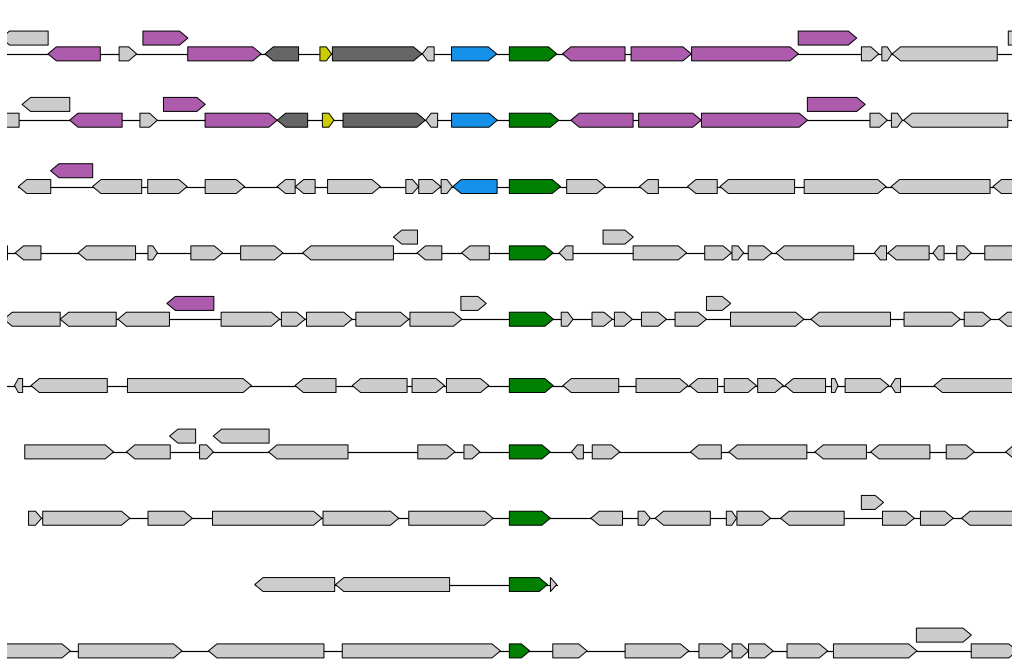

In [231]:
data_to_plot = [
    ('GCF_000731985.1', 'WP_007110057.1'),       # Natrinema altunense
    ('GCF_000230735.2', 'WP_015299281.1'),       # Natrinema pellirubrum
    ('GCF_000025685.1', 'WP_004043226.1'),       # Haloferax volcanii
    ('GCF_001465795.2', 'WP_058381518.1'),       # Planococcus rifietoensis
    ('GCF_003226345.1', 'WP_110516892.1'),       # Alteribacter lacisalsi
    ('GCF_900166625.1', 'WP_082233103.1'),       # Halobacillus A massiliensis
    ('GCF_006742205.1', 'WP_002456424.1'),       # Staphylococcus epidermidis
    ('GCF_002902305.1', 'WP_103370993.1'),       # Staphylococcus argensis
    ('GCF_002902385.1', 'NZ_PPQH01000083.1_2'),  # Staphylococcus intermedius
    ('GCF_900636325.1', 'NZ_LR134263.1_321'),    # Staphylococcus delphini
]

for _, protein_id in data_to_plot:
    color_map[protein_id] = 'green'

n_rows = len(data_to_plot)
fig, axes = plt.subplots(n_rows, 1, figsize=(18, 1.2 * len(data_to_plot)))

max_display_length_left = 9_000
max_display_length_right = 9_000

for i, (accession, core_protein_id) in enumerate(data_to_plot):
    ax = axes[i]
    gtdb_species = gtdb_metadata.loc[accession, 'gtdb_species']

    gene_context = context_df.loc[
        [f'{core_protein_id}@{accession}']
    ].reset_index().set_index('protein_id')
    strand = gene_context.loc[core_protein_id, 'strand']

    if strand == '-':
        # Swap strand
        df = gene_context.reset_index()
        contig_length = df['end'].max()
        old_start = df['start'].copy()
        old_end = df['end'].copy()

        df['start'] = contig_length - old_end + 1
        df['end'] = contig_length - old_start + 1

        df['strand'] = df['strand'].map({'+': '-', '-': '+'})

        # Re-order genes by their new start position
        gene_context = df.sort_values(by='start').reset_index(drop=True).set_index('protein_id')

    ax = plot_genes(gene_context, ax=ax, no_labels=True, color_map=color_map);

    left = gene_context.loc[core_protein_id, 'start'] - max_display_length_left
    right = gene_context.loc[core_protein_id, 'start'] + max_display_length_right
    ax.set_xlim(left, right)
    ax.get_xaxis().set_visible(False)

fig.savefig(halc8_out / 'sequences' / 'gene_context' / 'gene_synteny.pdf', dpi=300, bbox_inches='tight')

### Keep immunity domain only

Cleave off signal peptide and halocin C8 C-terminal domain.
Protein structure of the (putative) immunity mechanism will further be predicted with AF3. 

In [ ]:
signalp6_subset = pd.read_csv(halc8_folder / 'sequences' / 'immunity' / 'signalp6_results.tsv', sep='\t')
signalp6_subset['id'] = signalp6_subset['ID'].apply(lambda v: v.split(' ')[0].replace('_GC', '@GC'))
signalp6_subset = signalp6_subset.drop(columns=['ID']).set_index('id')
signalp6_subset

,Prediction,OTHER,SP(Sec/SPI),LIPO(Sec/SPII),TAT(Tat/SPI),TATLIPO(Tat/SPII),PILIN(Sec/SPIII),CS Position
id,,,,,,,,
WP_007110057.1@GCF_000731985.1,TAT,0.000000,0.000001,0.000000,0.985906,0.014070,0.000000,CS pos: 39-40. Pr: 0.8680
WP_103159623.1@GCF_002901945.1,SP,0.000731,0.733574,0.264985,0.000262,0.000238,0.000196,CS pos: 28-29. Pr: 0.6893
NZ_LR134263.1_321@GCF_900636325.1,OTHER,1.000000,0.000011,0.000002,0.000000,0.000000,0.000000,NaN
WP_002456424.1@GCF_006742205.1,SP,0.001279,0.869989,0.127866,0.000362,0.000266,0.000208,CS pos: 28-29. Pr: 0.8210
WP_103370993.1@GCF_002902305.1,SP,0.000681,0.685836,0.312576,0.000333,0.000301,0.000234,CS pos: 28-29. Pr: 0.6457
NZ_PPQH01000083.1_2@GCF_002902385.1,OTHER,0.998639,0.001410,0.000005,0.000002,0.000001,0.000002,NaN


In [ ]:
sequences = SeqIO.to_dict(SeqIO.parse(halc8_out / 'sequences' / 'HalC8_GTDB_r214_hits.fasta', 'fasta'))

trimmed_records = []
for sequence_id in signalp6_subset.index:
    record = sequences[sequence_id]

    signalp_row = signalp6_subset.loc[sequence_id]
    if signalp_row['Prediction'] != 'OTHER':
        m = re.match(r'CS pos: ([0-9]+)-([0-9]+).', signalp_row['CS Position'])
        signal_end = int(m[2])

        record.seq = record.seq[signal_end:]

    df = domains[
        (domains['target'] == sequence_id) &
        (domains['query'] == 'TIGR04449')
    ]
    assert len(df) == 1

    domain_row = df.iloc[0]
    domain_start = int(domain_row['from'])
    
    record.seq = record.seq[:domain_start]

    trimmed_records.append(record)

with (halc8_out / 'sequences' / 'immunity' / 'immunity_only.fasta').open('w') as f_out:
    SeqIO.write(trimmed_records, f_out, 'fasta')

## Staphylococcus

In [10]:
staph_metadata = gtdb_metadata.loc[halc8_hits[halc8_hits['gtdb_genus'] == 'Staphylococcus']['assembly_accession'].unique()]
staph_metadata[['gtdb_species', 'gtdb_representative']]

,gtdb_species,gtdb_representative
assembly_accession,,
GCF_002902305.1,Staphylococcus argensis,t
GCF_002901945.1,Staphylococcus chromogenes,t
GCF_900636325.1,Staphylococcus delphini,t
GCF_006742205.1,Staphylococcus epidermidis,t
GCF_002902385.1,Staphylococcus intermedius,t


In [18]:
gtdb_metadata_all_bacteria = pd.read_csv(data_folder / 'gtdb_r214.1' / 'bac120_metadata_r214.tsv', sep='\t')
gtdb_metadata_all_bacteria['assembly_accession'] = gtdb_metadata_all_bacteria['accession'].apply(lambda v: v[3:])
gtdb_metadata_all_bacteria = gtdb_metadata_all_bacteria.set_index('assembly_accession')

staph_gtdb_metadata = gtdb_metadata_all_bacteria[
    gtdb_metadata_all_bacteria['gtdb_taxonomy'].str.contains('g__Staphylococcus') &
    (gtdb_metadata_all_bacteria['gtdb_representative'] == 't')
].copy()
gtdb_metadata_all_bacteria = None

staph_gtdb_metadata['gtdb_species'] = staph_gtdb_metadata['gtdb_taxonomy'].apply(lambda t: t.split(';')[-1].replace('s__', ''))
len(staph_gtdb_metadata)

/opt/homebrew/Caskroom/miniforge/base/envs/amp/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (61,63,65,74,82,83) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


77

In [20]:
bac_tree = Phylo.read(data_folder / 'gtdb_r214.1' / 'bac120_r214.tree', 'newick')

staph_tree = prune_leaves_with_unknown_id(bac_tree, set(staph_gtdb_metadata['accession'].unique()))

assert len(staph_tree.get_terminals()) == len(staph_gtdb_metadata)

Phylo.write([staph_tree], halc8_out / 'staph_species_tree' / 'staph.tree', 'newick')

1

In [21]:
staph_labels = []
for accession, gtdb_species in staph_gtdb_metadata[['accession', 'gtdb_species']].values:
    staph_labels.append([accession, gtdb_species])

itol_labels(
    staph_labels,
    halc8_out / 'staph_species_tree' / 'labels.txt'
)

In [23]:
halc8_annotation_data = []
for accession in sorted(set(staph_gtdb_metadata.index)):
    tree_id = staph_gtdb_metadata.loc[accession, 'accession']

    if accession in staph_metadata.index:
        colour = '#9F2B68'
        label = 'Halocin C8'
    else:
        colour = '#FFFFFF'
        label = 'None'
    
    halc8_annotation_data.append([tree_id, colour, label])

itol_color_strip_annotations(
    halc8_annotation_data,
    halc8_out / 'staph_species_tree' / 'halc8_annotation.txt',
    dataset_label='Halocin C8',
    legend_title='Halocin C8',
    color_branches=False,
)